> Das Essen soll zuerst das Auge erfreuen und dann den Magen

___

In dieser Kurseinheit werden wir uns mit der Analyse von Daten beschäftigen und einige Techniken zur Visualisierung von Daten anwenden. 

**_Bitte beachten:_**

- In Raw-Zellen erwarten wir Antworten im Freitext-Format. In Code-Zellen soll Code eingefügt werden, bei Bedarf mit Kommentaren. Weitere Formate werden mit Markdown bearbeitet
- Fragestellungen sind teilweise bewusst etwas offener formuliert, weil Sie auch im Arbeitsleben nur selten mit ganz spezifischen Anweisungen rechnen können. Es gibt häufig mehrere mögliche Lösungen, dies wird in der Korrektur berücksichtigt.

Für die Datenvisualisierung verwenden wir die Bibliothek <a href="https://matplotlib.org/stable/index.html">`matplotlib`</a> innerhalb der Jupyter-Notebook-Zellen. Sie können jedoch auch andere Bibliotheken wie <a href="https://seaborn.pydata.org/">`seaborn`</a> verwenden. Wenn Sie eine bestimmte Bibliothek verwenden möchten, stellen Sie bitte sicher, dass die entsprechende Bibliothek installiert und importiert ist.

___

Ziel ist es, die Zugänglichkeit von Lebensmitteln und Trinkwasser für die Bevölkerung in Deutschland zu analysieren.
Wir arbeiten weiter mit den Datensätzen Refill-Deutschland und Mundraub. Refill-Deutschland und Mundraub sind Plattformen, die die Standorte von Früchten, Pflanzen und Zapfstellen in Deutschland erfassen. Beide Datensätze stammen aus <a href="https://www.govdata.de/">GovData</a> und beinhalten geographische Punkte, an denen es freien Zugang zu Wasser und Lebensmittel gibt.

In den vorangegangenen Übungen wurden einige Probleme und Informationslücken im Datensatz identifiziert und korrigiert. Es wurde verstanden, warum Data Wrangling ein zirkulärer Prozess ist. 

Die Verwendung externer Quellen und das Einfügen von Anmerkungen am Ende des Protokolls ist weiterhin erlaubt! :)

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Laden Sie den Datensatz von Refill-Deutschland in ein Dataframe mit dem Namen `df_refill` und den Datensatz von Mundraub in ein Dataframe mit dem Namen `df_mundraub`. Verwenden Sie die Spalte `FID` als Index. Verwenden Sie die Datensätze aus Moodle (`refill_preprocessed.csv` und `mundraub_preprocessed.csv`), diese beinhalten alle Vorverarbeitungsschritte, die wir in den Aufgaben aus KE3 durchgeführt haben. Zudem wurde im Mundraub-Datensatz noch eine weitere Spalte `rating` hinzugefügt.

In [2]:
# Datensatz laden
df_refill = pd.read_csv("KE4/refill_preprocessed.csv", index_col=1)
df_mundraub = pd.read_csv("KE4/mundraub_preprocessed.csv", index_col=0)

# Tendency
Die folgenden Aufgaben sollen Ihnen helfen, die Bedeutung des Begriffs "typisch" in der Datenanalyse zu verstehen. Ziel ist es, die Vor- und Nachteile der Verwendung von Mittelwert und der Median zu untersuchen.

## Was für ein 'ranking'
Die Spalte `rating` enthält fehlende Werte. Die fehlenden Werte wurden jeweils durch die Werte _1_, _3_ und _5_ ersetzt. Betrachten Sie das folgende Diagramm: Wie wirken sich die unterschiedlichen Imputationen auf den Median und den Mittelwert aus? Notieren Sie Ihre Erklärung in der Raw-Zelle unterhalb des Diagramms.

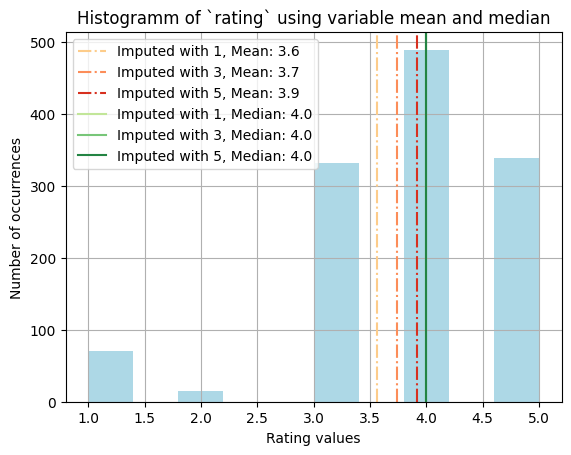

In [4]:
pltRating = df_mundraub.rating.hist(color='lightblue')

lineColors = ['#fdcc8a', '#c2e699', # yellow, lightGreen
              '#fc8d59', '#78c679', # orange, green
              '#d7301f', '#238443'] # red,    darkGreen

mean_handles = []
mean_labels = []
median_handles = []
median_labels = []

for i in range(1, 6, 2):
    rat = df_mundraub.rating.fillna(i)
    
    # Calculate mean and median
    ratingMean = rat.mean()
    ratingMedian = rat.median()

    # Plot mean and median, and store the handles and labels
    hMean = pltRating.axvline(ratingMean, ls='-.', color=lineColors[i-1])
    hMedian = pltRating.axvline(ratingMedian, ls='-', color=lineColors[i])
    
    # Store handles and labels with Mean first and Median second
    mean_handles.append(hMean)
    mean_labels.append(f'Imputed with {i}, Mean: {ratingMean:.1f}')
    
    median_handles.append(hMedian)
    median_labels.append(f'Imputed with {i}, Median: {ratingMedian:.1f}')

handles = mean_handles + median_handles
labels = mean_labels + median_labels

# Pass the updated handles and labels to the legend
pltRating.legend(handles, labels)

plt.title('Histogramm of `rating` using variable mean and median')
plt.xlabel('Rating values')
plt.ylabel('Number of occurrences')

plt.show()

## Kräuterpfad
Als nächstes möchten wir herausfinden, wie häufig Produkte typischerweise geerntet werden können. Gehen Sie hierfür wie folgt vor:
- Zählen Sie pro `kind` die Werte
- Berechnen Sie den Median aller Werte
- Berechnen Sie den Mittelwert aller Werte
- Erstellen Sie ein Diagramm, das die Werte pro `kind` abbildet und außerdem den Mittelwert und den Median (wie bei der vorherigen Aufgabe) anzeigt

Diskutieren Sie anschließend in der untenstehenden Raw-Zelle die Unterschiede zwischen Median und Mittelwert.

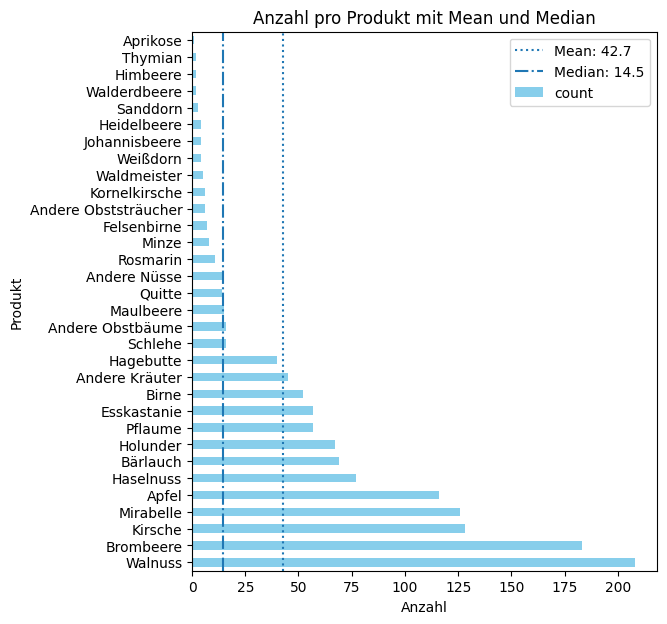

In [5]:
# Ihre Lösung
eatable_counts = df_mundraub.kind.value_counts()
eatable_mean = eatable_counts.mean()
eatable_median = eatable_counts.median()

axKraeuterpfad = eatable_counts.plot(kind='barh', 
                                     color='skyblue', 
                                     fontsize=10,
                                     figsize=(6, 7))

plt.axvline(eatable_mean, ls=':', label=f'Mean: {eatable_mean:.1f}')
plt.axvline(eatable_median, ls='-.', label=f'Median: {eatable_median:.1f}')

plt.title('Anzahl pro Produkt mit Mean und Median')
plt.xlabel('Anzahl')
plt.ylabel('Produkt')
plt.legend()
plt.show()

## Die wichtigere Hälfte
In welchen Situationen ist der Mittelwert und in welchen der Median aussagekräftiger? Erläutern Sie den Unterschied.

# Data Visualisierung
Die folgenden Aufgaben beziehen sich auf die Visualisierung von Daten. Das Ziel ist es, die Lesbarkeit der Diagramme zu verbessern und die relevanten Elemente des Diagramms zu erkennen.

## Finde den Fehler
Die folgenden Aufgaben enthalten vorgefertigten Code, um Diagramme zu erstellen. Führen Sie sie aus (ohne den Code zu verändern) und analysieren Sie die Diagramme: Ziel ist es, eine Liste von Verbesserungen zu erstellen und anhand der Kriterien aus _Kapitel 10 "Presenting Your Data"_ des Buches von _McGregor_ zu erläutern, ob die gewählten Diagrammtypen geeignet sind oder nicht. Begründen Sie Ihre Aussagen!

### I know what you did last summer
Das folgende Diagramm soll die Anzahl neuer Mundraub-Stationen nach Jahren und Monaten vergleichen.

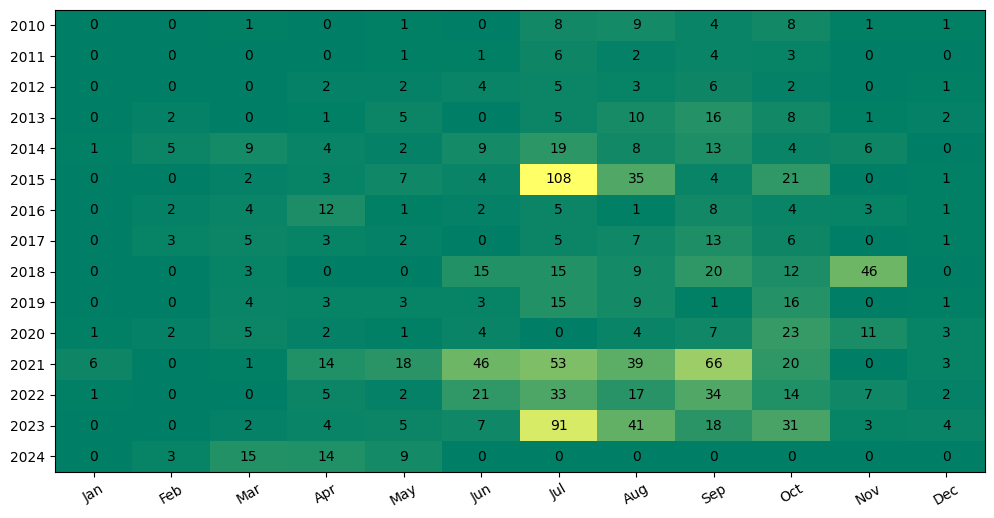

In [6]:
created = pd.to_datetime(df_mundraub.created_at, format='%Y-%m-%d %H:%M:%S')

monthNames = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df = pd.DataFrame(created)
df['year'] = created.dt.year
df['month'] = created.dt.month

field = df.pivot_table(index='year', columns='month', aggfunc='size', fill_value=0)

figureYearMonthAggregation = plt.figure(figsize=(12, 6))
plt.imshow(field, cmap = 'summer', aspect='auto')

plt.xticks(range(12), labels=monthNames, rotation=30)
plt.yticks(range(15), labels=field.index)

# Add the cell values
for i in range(len(field.index)):
    for j in range(len(field.columns)):
        plt.text(j, i, field.iloc[i, j], 
                 ha='center', 
                 va='center', 
                 color='black')

Wurde der richtige Diagrammtyp verwendet? Falls nicht, welchen anderen Diagrammtyp würden Sie bevorzugen? Bitte begründen Sie Ihre Antwort.

### Paket unzustellbar III
Mit der Erstellung der folgenden Diagramms soll die Häufigkeit der Postleitzahlen verglichen werden.

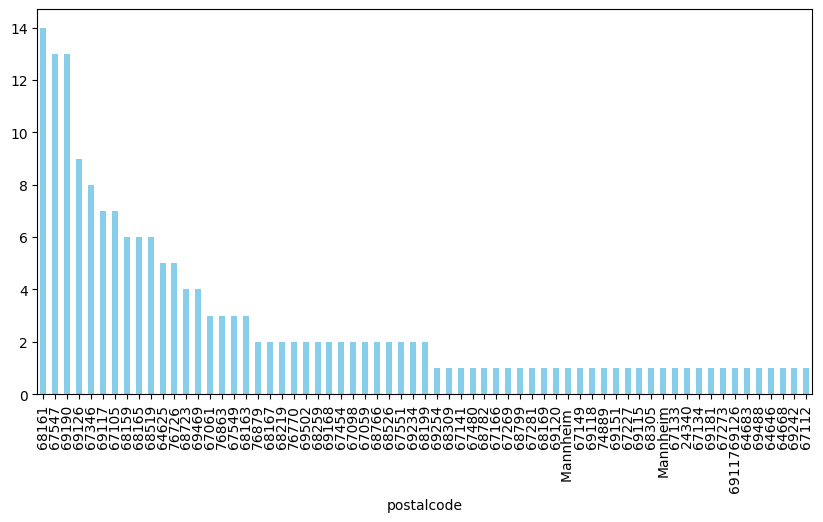

In [7]:
axPaketUnzustellbar = df_refill.postalcode.value_counts().plot(kind='bar', 
                                                          color='skyblue', 
                                                          figsize=(10, 5))
plt.show()
figurePaketUnzustellbar = axPaketUnzustellbar.get_figure()

Wurde der richtige Diagrammtyp verwendet? Falls nicht, welchen anderen Diagrammtyp würden Sie bevorzugen? Bitte begründen Sie Ihre Antwort.

***Zusatzaufgabe***

Im obigen Diagramm lässt sich eine Inkonsistenz finden, bereinigen Sie diese.

In [ ]:
# Platz für Tests und Analysen
print(df_refill.loc[df_refill['postalcode'].str.contains('Mannheim', case=False), ['city', 'address']], "\n")
print(df_refill.loc[df_refill['postalcode'] == '6911769126', ['city', 'address']])

In [ ]:
# Ihre Lösung
df_refill.loc['MRN_Refill_4326_Point.88', ['postalcode', 'city']] = ['68199', 'Mannheim']
df_refill.loc['MRN_Refill_4326_Point.93', ['postalcode', 'city']] = ['68161', 'Mannheim']

df_refill.loc['MRN_Refill_4326_Point.130', 'postalcode'] = '69126'

### Wohin das Wasser geht
Im folgenden Diagramm werden nur jene Stationen betrachtet, deren Titel das Wort "Wasser" oder "Brunnen" enthält. Hier soll analysiert werden, in welcher Stadt es am meisten solcher Stationen gibt.

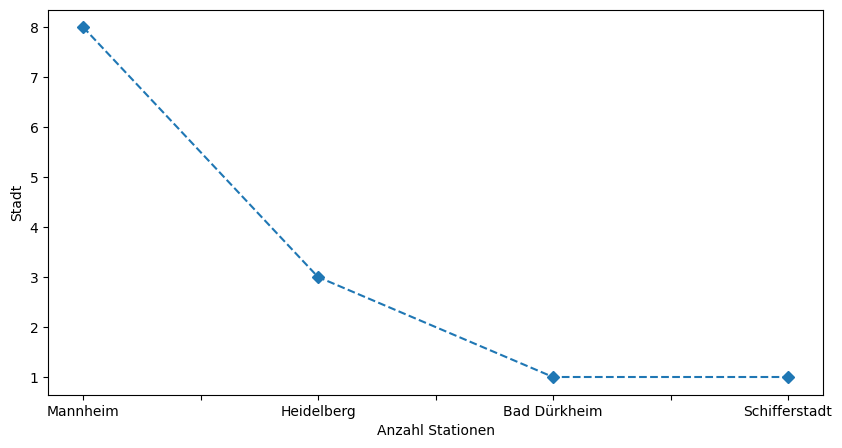

In [8]:
filtered_df = df_refill[df_refill.stationsname.str.contains(r"wasser|brunnen", case=False, na=False)]

filtered_df.city.value_counts().plot(kind='line',\
                              ls='--',\
                              marker='D',\
                              snap=True,\
                              figsize=(10,5), \
                              xlabel='Anzahl Stationen',\
                              ylabel='Stadt')

plt.show()

Wurde der richtige Diagrammtyp verwendet? Falls nicht, welchen anderen Diagrammtyp würden Sie bevorzugen? Bitte begründen Sie Ihre Antwort.

## The choice is yours

In den folgenden Aufgaben erstellen Sie eigene Diagramme. Die Fragestellungen sind vorgegeben, jedoch liegt die Wahl der Diagrammarten sowie deren Gestaltung in Ihrer Verantwortung. Orientieren Sie sich dabei an den Grundlagen der Eloquenz (vgl. _Kapitel 10_ in _McGregor_). Gehen Sie dabei wie folgt vor:

1. Fügen Sie in den Code-Zellen den Code ein, um die entsprechenden Diagramme zu erzeugen.

2.  Notieren Sie in den Raw-Zellen jeweils - neben der Antwort auf die eigentliche Fragestellung - die für Sie relevanten Aspekte des Diagramms:
 - **Focus refinement**: Welches Element des Diagramms hilft am besten, die Hauptidee zu vermitteln?
 - **Visual form**: Warum wurde dieser Diagrammtyp als beste visuelle Form zur Darstellung der Daten gewählt? Orientieren Sie sich dabei an den Regeln und Richtlinien, die in Kapitel 10 im Buch von McGregor für die Diagrammtypen angegeben werden.
 - **Clarity and meaning enhancement**: Welche visuelle Strukturen (Titel, etc.) haben Sie ergänzt, die zu einer Verbesserung der Ausdruckskraft beitragen?

### Und am siebten Tag ist Ruhe?
Wir möchten gerne wissen: An welchem Wochentag wurden die meisten Stationen in den Mundraub-Datensatz aufgenommen? Tragen Sie die Antwort und die o.g. Aspekte in die untenstehende Raw-Zelle ein.

Als Hilfestellung ist ein Teil des Codes bereits vorgegeben.

In [9]:
created = pd.to_datetime(df_mundraub.created_at, format='%Y-%m-%d %H:%M:%S')

weekMap = { 0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', \
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

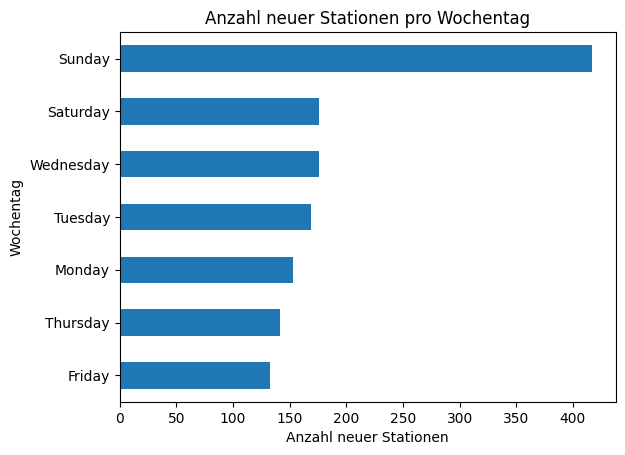

In [10]:
# Ihre Lösung
weekday_counts = created.dt.weekday.value_counts().sort_index()
weekday_counts.index = weekday_counts.index.map(weekMap)

axWeeklyAggregation = weekday_counts.sort_values().plot.barh()

plt.xlabel('Anzahl neuer Stationen')
plt.ylabel('Wochentag')
plt.title('Anzahl neuer Stationen pro Wochentag')
plt.show()

### Jährliche Entwicklung
Anhand eines Diagramms möchten wir wissen: Wie entwickelt sich die Aufnahme neuer Mundraubstationen über die Jahre? Gab es Zeiten, in denen besonders viele neue Stationen registriert wurden? Schreiben Sie die Antwort sowie die o.g. Aspekte wiederum in die untenstehende Raw-Zelle.

*Hinweis: Verwenden Sie die Variable `created`, die in der vorherigen Aufgabe erstellt wurde.*

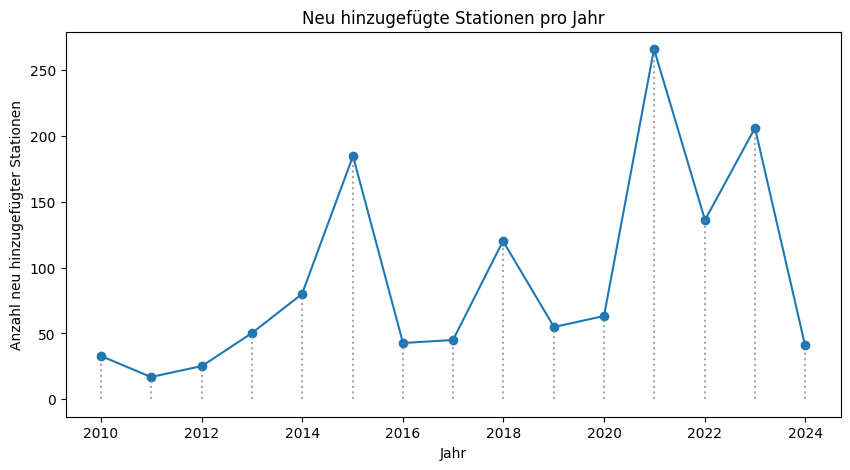

In [11]:
# Ihre Lösung
created_year = created.dt.year.value_counts().sort_index()
axYearAgg = created_year.plot(kind="line",\
                              ls='-',\
                              marker="o",\
                              snap=True,\
                              figsize=(10,5), \
                              title='Neu hinzugefügte Stationen pro Jahr',\
                              xlabel='Jahr',\
                              ylabel='Anzahl neu hinzugefügter Stationen')

for x, y in zip(created_year.index, created_year.values):
    plt.plot([x, x], [0, y], linestyle=':', color='gray', alpha=0.7)
    
plt.show()

### Mundraub-Backen
In der nächsten Codezelle haben wir die Ernteprodukte in vier Gruppen eingeteilt: ("Fruit Trees", "Bushes", "Nuts" und "Herbs"). Verwenden Sie diese Einteilung, um in der darauffolgenden Code-Zelle ein Diagramm zu erstellen, das zeigt, wie sich der Datensatz von Mundraub zusammensetzt. Welches Produkt ist am meisten enthalten? Schreiben Sie anschließend wiederum die Antwort und die o.g. Aspekte in die entsprechende Raw-Zelle.

In [12]:
harvestClassification = {
    "Fruit Trees":{ "Apfel", "Kirsche", "Quitte", "Aprikose", "Pflaume", 
                   "Mirabelle", "Birne", "Maulbeere", "Felsenbirne", 
                  "Kornelkirsche", "Andere Obstbäume" },
    
    "Bushes":{ "Brombeere", "Holunder", "Schlehe", "Johannisbeere", 
               "Himbeere", "Heidelbeere", "Walderdbeere", "Sanddorn", 
              "Weißdorn", "Hagebutte", "Andere Obststräucher" },
    
    "Nuts":{ "Haselnuss", "Walnuss", "Esskastanie", "Andere Nüsse" },
    
    "Herbs":{ "Bärlauch", "Rosmarin", "Minze", "Waldmeister", "Thymian", 
             "Andere Kräuter" }
}

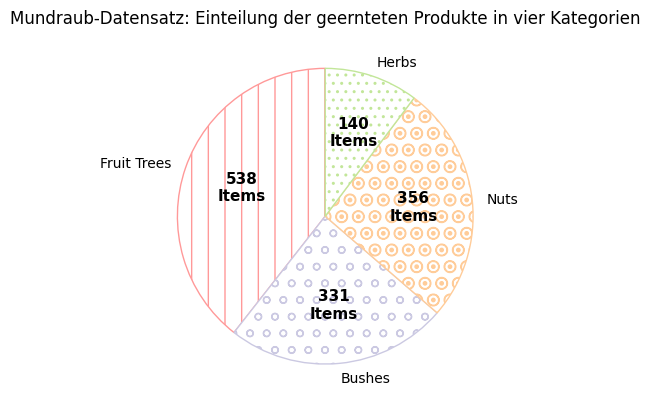

In [14]:
# Ihre Lösung
harvestSum = {"Fruit Trees":0, "Bushes":0, "Nuts":0, "Herbs":0}

kindCounts = df_mundraub.kind.value_counts()
for kind, count in kindCounts.items():
    for category, items in harvestClassification.items():
        if kind in items:
            harvestSum[category]+=count

groupLabels = list(harvestSum.keys())
groupSizes = list(harvestSum.values())

#                carrot    blue      yellow     green
groupColors = ['#ff9999','#cbc9e2','#ffcc99', '#c2e699' ]
patt = ['|', 'o', 'O.', '..']

figureMundraubBacken, ax = plt.subplots()
piechart = ax.pie(groupSizes, 
                  labels=groupLabels,
                  startangle=90, 
                  autopct=lambda p:f'{p*sum(groupSizes)/100 :.0f}\nItems')

plt.setp(piechart[2], size=11, weight="bold")

for i in range(len(piechart[0])):
    piechart[0][i].set_hatch(patt[(i)%len(patt)])
    piechart[0][i].set_facecolor('white')
    piechart[0][i].set_edgecolor(groupColors[i])
    

plt.title('Mundraub-Datensatz: Einteilung der geernteten Produkte in vier Kategorien')

plt.show()

# Notizen
Persönliche Notizen ;)